# Apex Realty AI – California Housing Price Prediction


## Project Objective

The objective of this project is to predict residential housing market prices using the California Housing dataset.

### Target
Median House Value

### Primary Evaluation Metrics
- RMSE
- MAE
- R²
- Residual Analysis

### Role
Data Engineer – Member 1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from pathlib import Path
import pandas as pd
from sklearn.datasets import fetch_california_housing

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Create the raw data folder
raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

print("Raw data folder is ready!")

Raw data folder is ready!


In [7]:
# Download and load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert dataset into a DataFrame
df = housing.frame

print("Dataset downloaded and loaded successfully!")
print("Dataset shape:", df.shape)

Dataset downloaded and loaded successfully!
Dataset shape: (20640, 9)


In [8]:
# Save the original dataset without modifying it
raw_file = raw_dir / "california_housing.csv"

df.to_csv(raw_file, index=False)

print("Raw dataset saved successfully!")
print("File location:", raw_file)

Raw dataset saved successfully!
File location: ..\data\raw\california_housing.csv


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Rows: 20640
Columns: 9

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [10]:
from pathlib import Path
import pandas as pd

raw_file = Path("../data/raw/california_housing.csv")

df = pd.read_csv(raw_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20640, 9)


In [11]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [12]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

In [15]:
print("Minimum value of each column:")
print(df.min())

Minimum value of each column:
MedInc           0.499900
HouseAge         1.000000
AveRooms         0.846154
AveBedrms        0.333333
Population       3.000000
AveOccup         0.692308
Latitude        32.540000
Longitude     -124.350000
MedHouseVal      0.149990
dtype: float64


In [16]:
print("Maximum value of each column:")
print(df.max())

Maximum value of each column:
MedInc            15.000100
HouseAge          52.000000
AveRooms         141.909091
AveBedrms         34.066667
Population     35682.000000
AveOccup        1243.333333
Latitude          41.950000
Longitude       -114.310000
MedHouseVal        5.000010
dtype: float64


In [17]:
print("Invalid value checks:")

print("Negative MedInc:", (df["MedInc"] < 0).sum())
print("Invalid HouseAge:", (df["HouseAge"] <= 0).sum())
print("Invalid Population:", (df["Population"] <= 0).sum())
print("Invalid AveOccup:", (df["AveOccup"] <= 0).sum())

Invalid value checks:
Negative MedInc: 0
Invalid HouseAge: 0
Invalid Population: 0
Invalid AveOccup: 0


In [18]:
print("Invalid Latitude:", ((df["Latitude"] < -90) | (df["Latitude"] > 90)).sum())
print("Invalid Longitude:", ((df["Longitude"] < -180) | (df["Longitude"] > 180)).sum())

Invalid Latitude: 0
Invalid Longitude: 0


In [19]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((df < lower_bound) | (df > upper_bound)).sum()

print("Potential outliers using IQR:")
print(outlier_counts)

Potential outliers using IQR:
MedInc          681
HouseAge          0
AveRooms        511
AveBedrms      1424
Population     1196
AveOccup        711
Latitude          0
Longitude         0
MedHouseVal    1071
dtype: int64


In [20]:
print("Top 5 highest values:")

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].nlargest(5).values)

Top 5 highest values:

MedInc:
[15.0001 15.0001 15.0001 15.0001 15.0001]

HouseAge:
[52. 52. 52. 52. 52.]

AveRooms:
[141.90909091 132.53333333  62.42222222  61.8125      59.875     ]

AveBedrms:
[34.06666667 25.63636364 15.3125     14.11111111 11.41071429]

Population:
[35682. 28566. 16305. 16122. 15507.]

AveOccup:
[1243.33333333  599.71428571  502.46153846  230.17241379   83.17142857]

Latitude:
[41.95 41.95 41.92 41.88 41.86]

Longitude:
[-114.31 -114.47 -114.49 -114.55 -114.56]

MedHouseVal:
[5.00001 5.00001 5.00001 5.00001 5.00001]


In [21]:
outlier_summary = pd.DataFrame({
    "Column": outlier_counts.index,
    "Potential_Outliers_IQR": outlier_counts.values
})

print(outlier_summary)

        Column  Potential_Outliers_IQR
0       MedInc                     681
1     HouseAge                       0
2     AveRooms                     511
3    AveBedrms                    1424
4   Population                    1196
5     AveOccup                     711
6     Latitude                       0
7    Longitude                       0
8  MedHouseVal                    1071


In [22]:
clean_df = df.copy()

print("Cleaned dataset shape:", clean_df.shape)
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Cleaned dataset shape: (20640, 9)
Missing values: 0
Duplicate rows: 0


In [23]:
from pathlib import Path

processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

clean_file = processed_folder / "cleaned_california_housing.csv"

clean_df.to_csv(clean_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", clean_file)

Cleaned dataset saved successfully!
File: ..\data\processed\cleaned_california_housing.csv


In [24]:
# Separate features and target

X = clean_df.drop("MedHouseVal", axis=1)
y = clean_df["MedHouseVal"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target (y):
MedHouseVal

Feature shape: (20640, 8)
Target shape: (20640,)


In [25]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create preprocessing pipeline
preprocessor = Pipeline([
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created successfully!")
print(preprocessor)

Preprocessing pipeline created successfully!
Pipeline(steps=[('scaler', StandardScaler())])


In [27]:
# Fit the preprocessing pipeline only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Use the same fitted pipeline to transform test data
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (16512, 8)
Testing data after preprocessing: (4128, 8)


In [28]:
from pathlib import Path

processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

# Convert processed arrays into DataFrames
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=X.columns
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=X.columns
)

# Add target column
X_train_processed_df["MedHouseVal"] = y_train.values
X_test_processed_df["MedHouseVal"] = y_test.values

# Save processed datasets
X_train_processed_df.to_csv(
    processed_folder / "train_processed.csv",
    index=False
)

X_test_processed_df.to_csv(
    processed_folder / "test_processed.csv",
    index=False
)

print("Processed training and testing datasets saved successfully!")
print("Training file:", processed_folder / "train_processed.csv")
print("Testing file:", processed_folder / "test_processed.csv")

Processed training and testing datasets saved successfully!
Training file: ..\data\processed\train_processed.csv
Testing file: ..\data\processed\test_processed.csv


In [29]:
# Create data quality audit log

audit_log = pd.DataFrame({
    "Check": [
        "Dataset Shape",
        "Missing Values",
        "Duplicate Rows",
        "Invalid MedInc",
        "Invalid HouseAge",
        "Invalid Population",
        "Invalid AveOccup",
        "Invalid Latitude",
        "Invalid Longitude",
        "Potential Outliers"
    ],
    "Result": [
        str(df.shape),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int((df["MedInc"] < 0).sum()),
        int((df["HouseAge"] <= 0).sum()),
        int((df["Population"] <= 0).sum()),
        int((df["AveOccup"] <= 0).sum()),
        int(((df["Latitude"] < -90) | (df["Latitude"] > 90)).sum()),
        int(((df["Longitude"] < -180) | (df["Longitude"] > 180)).sum()),
        int(outlier_counts.sum())
    ]
})

print(audit_log)

                Check      Result
0       Dataset Shape  (20640, 9)
1      Missing Values           0
2      Duplicate Rows           0
3      Invalid MedInc           0
4    Invalid HouseAge           0
5  Invalid Population           0
6    Invalid AveOccup           0
7    Invalid Latitude           0
8   Invalid Longitude           0
9  Potential Outliers        5594


In [30]:
# Save data quality audit log

audit_file = processed_folder / "data_quality_audit.csv"

audit_log.to_csv(audit_file, index=False)

print("Data quality audit log saved successfully!")
print("File:", audit_file)

Data quality audit log saved successfully!
File: ..\data\processed\data_quality_audit.csv


# Exploratory Data Analysis (EDA)

**Data Analyst – Member 2**

This section provides statistical, distributional, and relational analysis of the California Housing dataset. 
All analysis uses raw (non-scaled) data to preserve original distributions and business interpretations.

## A. Statistical Summary & Data Understanding

We establish baseline statistics and understand key distributional properties of the data before visualization.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

raw_df = pd.read_csv("../data/raw/california_housing.csv")
features = [col for col in raw_df.columns if col != 'MedHouseVal']

print(f"Dataset: {raw_df.shape[0]:,} records × {raw_df.shape[1]} columns")

Dataset: 20,640 records × 9 columns


### Target Variable: Median House Value

Understanding the distribution of house prices is critical for regression modeling.

In [32]:
target = raw_df['MedHouseVal']

print("Mean:      ${:,.0f}".format(target.mean() * 100000))
print("Median:    ${:,.0f}".format(target.median() * 100000))
print("Std Dev:   ${:,.0f}".format(target.std() * 100000))
print("Min:       ${:,.0f}".format(target.min() * 100000))
print("Max:       ${:,.0f}".format(target.max() * 100000))
print("Range:     ${:,.0f}".format((target.max() - target.min()) * 100000))

Mean:      $206,856
Median:    $179,700
Std Dev:   $115,396
Min:       $14,999
Max:       $500,001
Range:     $485,002


In [33]:
skewness_val = stats.skew(target)
mean_val = target.mean()
median_val = target.median()

print(f"Skewness:  {skewness_val:.4f}")

if skewness_val > 0.5:
    print("\n✓ RIGHT-SKEWED distribution")
    print("  → More affordable homes; expensive homes are outliers")
elif skewness_val < -0.5:
    print("\n✓ LEFT-SKEWED distribution")
    print("  → More expensive homes; affordable homes are outliers")
else:
    print("\n✓ RELATIVELY SYMMETRIC distribution")

Skewness:  0.9777

✓ RIGHT-SKEWED distribution
  → More affordable homes; expensive homes are outliers


### Input Features: Variability Analysis

Which features change the most relative to their mean? This helps identify which variables might be harder to predict.

In [34]:
cv = (raw_df[features].std() / raw_df[features].mean()).sort_values(ascending=False)

print("Coefficient of Variation (std/mean):\n")
for i, (feat, val) in enumerate(cv.items(), 1):
    print(f"{i}. {feat:15s}  CV = {val:.4f}")

Coefficient of Variation (std/mean):

1. AveOccup         CV = 3.3824
2. Population       CV = 0.7944
3. MedInc           CV = 0.4908
4. AveRooms         CV = 0.4557
5. HouseAge         CV = 0.4394
6. AveBedrms        CV = 0.4321
7. Latitude         CV = 0.0599
8. Longitude        CV = -0.0168


### Key Takeaways from Statistical Summary

**Target Variable:**
- Right-skewed distribution (mean $206,856 > median $179,700)
- Suggests log transformation may improve model normality
- Wide range ($15k – $500k) indicates diverse price points

**Features:**
- **High variability:** AveOccup (CV=3.38), Population (CV=0.79)
  - More unpredictable; may require feature engineering
- **Low variability:** Geographic features (Latitude CV=0.06, Longitude CV=0.02)
  - Very consistent; likely important but less noisy

**For Modeling:**
- Consider log-transformation of target variable (due to right-skew)
- High-CV features may benefit from polynomial/interaction terms
- Geographic features should be prioritized for feature importance analysis

## B. Target Distribution Analysis

Visual exploration of the target variable (MedHouseVal) distribution to understand shape, normality, and potential transformations needed for modeling.

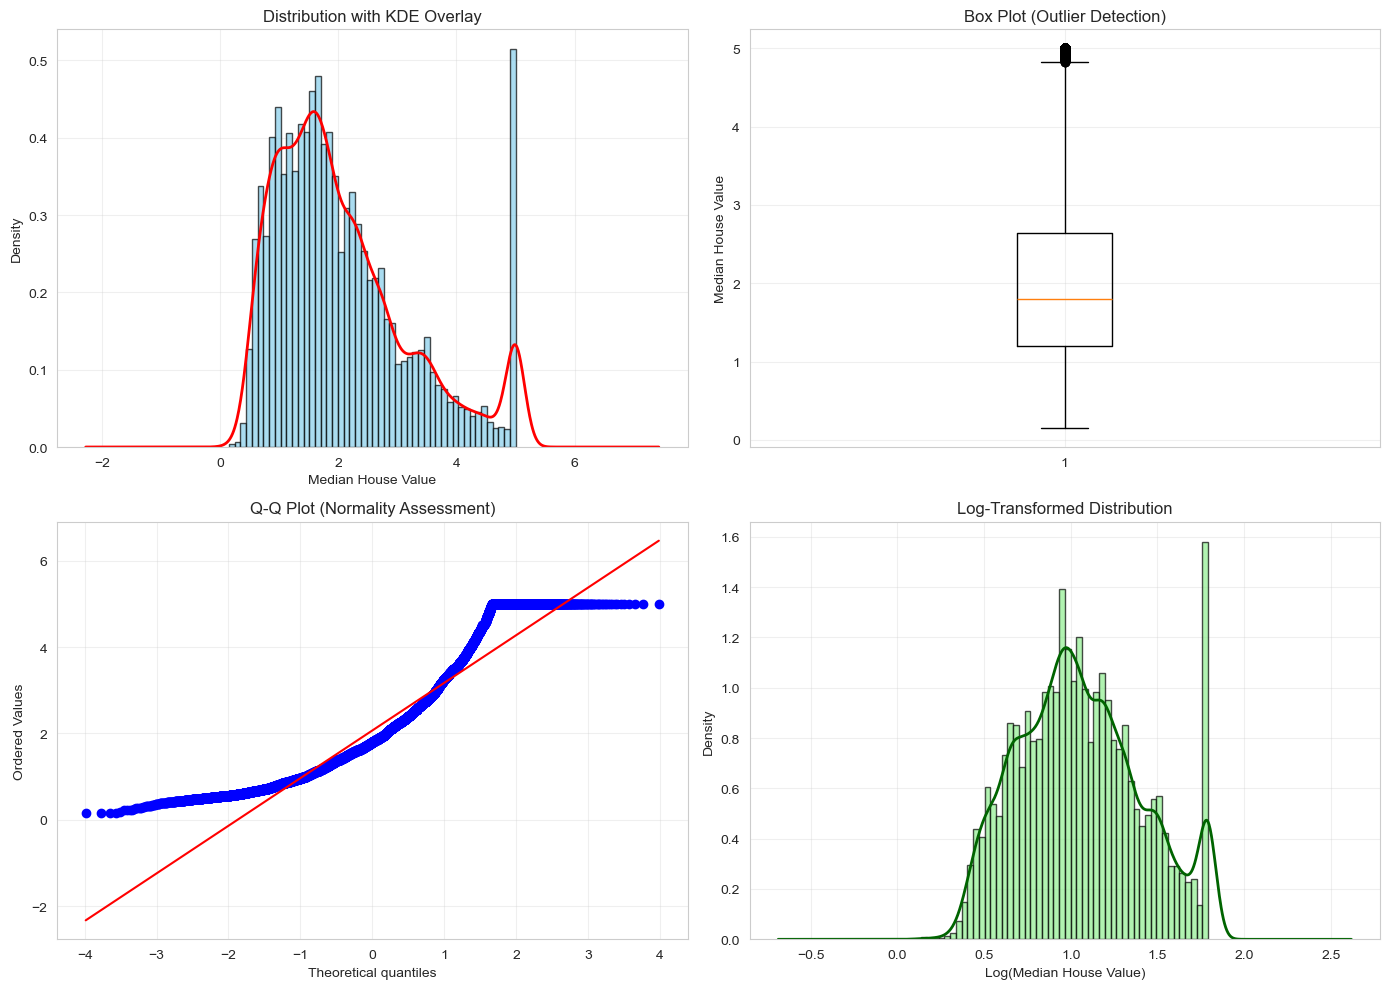

✓ Plot saved to visuals/target_distribution.png


In [54]:
# Create 2x2 subplot figure for target distribution
import os

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

target = raw_df['MedHouseVal']

# Plot 1: Histogram with KDE
axes[0, 0].hist(target, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
target.plot(kind='kde', ax=axes[0, 0], color='red', linewidth=2)
axes[0, 0].set_xlabel('Median House Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Distribution with KDE Overlay')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box Plot
axes[0, 1].boxplot(target, vert=True)
axes[0, 1].set_ylabel('Median House Value')
axes[0, 1].set_title('Box Plot (Outlier Detection)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Q-Q Plot
stats.probplot(target, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Assessment)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Log-Transformed Distribution
log_target = np.log1p(target)
axes[1, 1].hist(log_target, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
log_target.plot(kind='kde', ax=axes[1, 1], color='darkgreen', linewidth=2)
axes[1, 1].set_xlabel('Log(Median House Value)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Log-Transformed Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Ensure folder exists and save
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to visuals/target_distribution.png")

### Distribution Characteristics

In [36]:
target = raw_df['MedHouseVal']

# Calculate distribution metrics
print("DISTRIBUTION METRICS:\n")
print(f"Mean:        {target.mean():.4f}")
print(f"Median:      {target.median():.4f}")
print(f"Mode:        {target.mode()[0]:.4f}")
print(f"Std Dev:     {target.std():.4f}")
print(f"Skewness:    {stats.skew(target):.4f}")
print(f"Kurtosis:    {stats.kurtosis(target):.4f}")

# Normality test (Shapiro-Wilk)
print("\nNORMALITY TESTS:\n")
stat, p_value = stats.shapiro(target)
print(f"Shapiro-Wilk Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  P-value:   {p_value:.2e}")
if p_value < 0.05:
    print("  ✗ NOT normally distributed (p < 0.05)")
else:
    print("  ✓ Normally distributed (p ≥ 0.05)")

# Test log-transformed data
print("\nLog-Transformed Normality:\n")
log_target = np.log1p(target)
stat_log, p_value_log = stats.shapiro(log_target)
print(f"Shapiro-Wilk Test (Log-transformed):")
print(f"  Statistic: {stat_log:.4f}")
print(f"  P-value:   {p_value_log:.2e}")
if p_value_log < 0.05:
    print("  ✗ NOT normally distributed (p < 0.05)")
else:
    print("  ✓ Normally distributed (p ≥ 0.05)")

# Calculate improvement
improvement = abs(stats.skew(log_target)) - abs(stats.skew(target))
print(f"\nSkewness Improvement:")
print(f"  Original skewness:     {stats.skew(target):.4f}")
print(f"  Log-transformed:       {stats.skew(log_target):.4f}")
print(f"  Improvement:           {improvement:.4f}")

DISTRIBUTION METRICS:

Mean:        2.0686
Median:      1.7970
Mode:        5.0000
Std Dev:     1.1540
Skewness:    0.9777
Kurtosis:    0.3275

NORMALITY TESTS:

Shapiro-Wilk Test:
  Statistic: 0.9123
  P-value:   1.37e-74
  ✗ NOT normally distributed (p < 0.05)

Log-Transformed Normality:

Shapiro-Wilk Test (Log-transformed):
  Statistic: 0.9787
  P-value:   3.29e-47
  ✗ NOT normally distributed (p < 0.05)

Skewness Improvement:
  Original skewness:     0.9777
  Log-transformed:       0.2759
  Improvement:           -0.7018


c:\Users\sania\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20640.
  res = hypotest_fun_out(*samples, **kwds)


### Distribution Interpretation

**Raw Distribution:**
- Right-skewed (mean > median)
- Not normally distributed (fails Shapiro-Wilk test)
- Long tail of expensive homes

**After Log Transformation:**
- More symmetric distribution
- Closer to normal distribution
- Better for regression modeling

**Recommendation:**
Consider evaluating a log transformation of the target variable during model experimentation, as it may help reduce the effect of the right-skewed distribution. The Data Scientist should compare performance with and without the transformation using RMSE, MAE, and R².

## C. Feature Distributions & Skewness Analysis

Understanding the distribution of input features helps us decide which variables need transformation and which features might be most informative for predicting house prices.

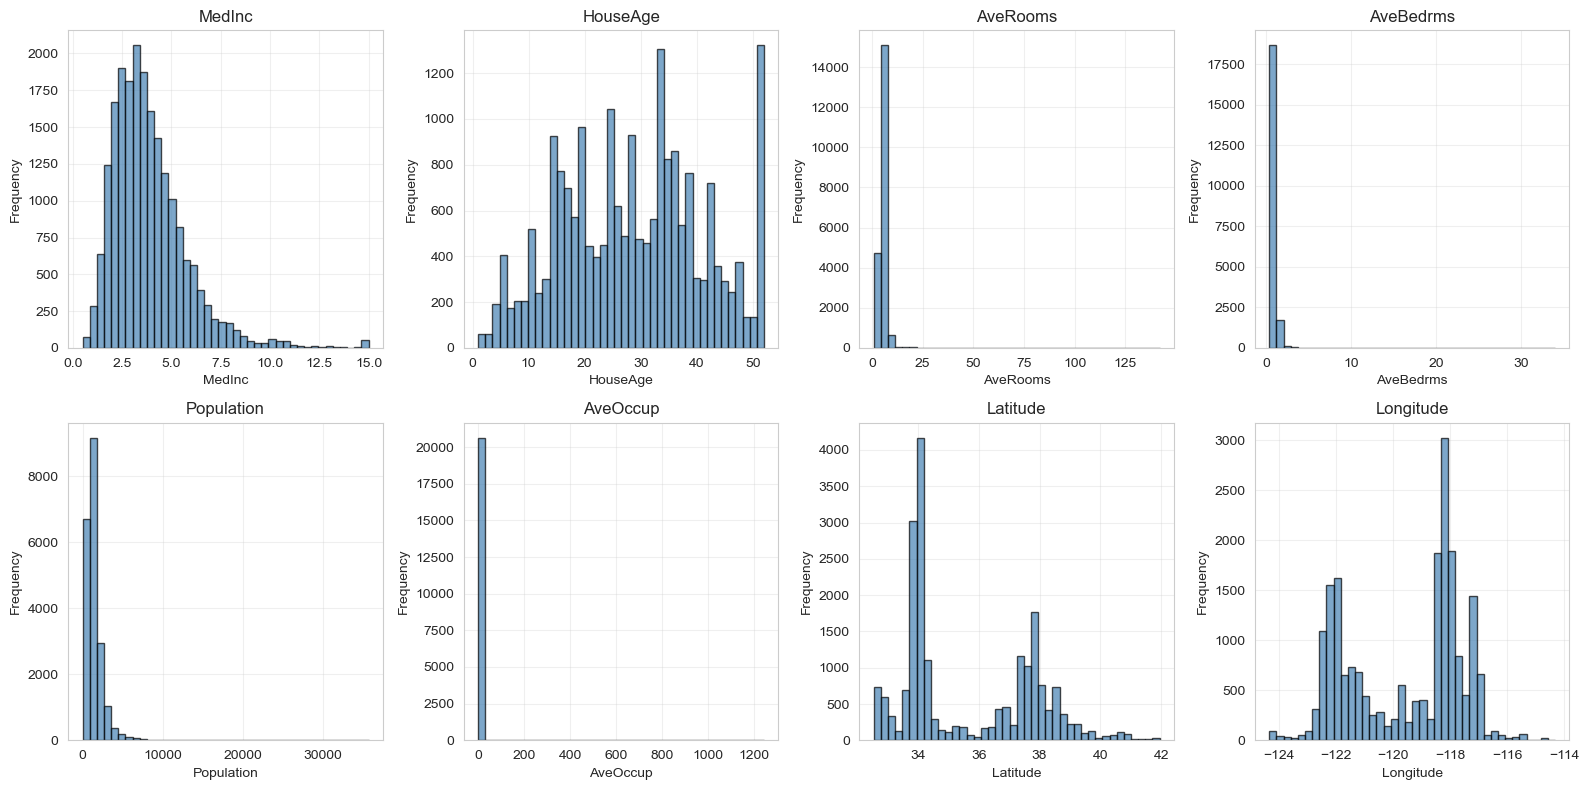

✓ Plot saved to visuals/feature_distributions.png


In [37]:
# Create 2x4 subplot grid for all 8 features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].hist(raw_df[feature], bins=40, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feature}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to visuals/feature_distributions.png")

### Skewness and Distribution Shape

Which features are skewed? Which are symmetric? This helps us decide on transformations.

In [41]:
# Calculate skewness and kurtosis for all features
skewness_data = []

for feature in features:
    skew_val = stats.skew(raw_df[feature])
    kurt_val = stats.kurtosis(raw_df[feature])
    skewness_data.append({
        'Feature': feature,
        'Mean': raw_df[feature].mean(),
        'Std Dev': raw_df[feature].std(),
        'Skewness': skew_val,
        'Kurtosis': kurt_val
    })

skewness_df = pd.DataFrame(skewness_data)

print("FEATURE SKEWNESS & KURTOSIS:\n")
print(skewness_df.to_string(index=False))


print("\n\nINTERPRETATION:\n")


for _, row in skewness_df.iterrows():
    skew = abs(row['Skewness'])
    feature = row['Feature']
    
    if skew > 1:
        print(f"⚠️  {feature:15s}: HIGHLY skewed ({row['Skewness']:7.4f})")
        print(f"    → Consider log/box-cox transformation")
    elif skew > 0.5:
        print(f"⚠️  {feature:15s}: MODERATELY skewed ({row['Skewness']:7.4f})")
    else:
        print(f"✓ {feature:15s}: RELATIVELY symmetric ({row['Skewness']:7.4f})")

FEATURE SKEWNESS & KURTOSIS:

   Feature        Mean     Std Dev  Skewness     Kurtosis
    MedInc    3.870671    1.899822  1.646537     4.951034
  HouseAge   28.639486   12.585558  0.060326    -0.800726
  AveRooms    5.429000    2.474173 20.696365   879.139966
 AveBedrms    1.096675    0.473911 31.314680  1636.315218
Population 1425.476744 1132.462122  4.935500    73.535009
  AveOccup    3.070655   10.386050 97.632465 10648.430334
  Latitude   35.631861    2.135952  0.465919    -1.117780
 Longitude -119.569704    2.003532 -0.297780    -1.330121


INTERPRETATION:

⚠️  MedInc         : HIGHLY skewed ( 1.6465)
    → Consider log/box-cox transformation
✓ HouseAge       : RELATIVELY symmetric ( 0.0603)
⚠️  AveRooms       : HIGHLY skewed (20.6964)
    → Consider log/box-cox transformation
⚠️  AveBedrms      : HIGHLY skewed (31.3147)
    → Consider log/box-cox transformation
⚠️  Population     : HIGHLY skewed ( 4.9355)
    → Consider log/box-cox transformation
⚠️  AveOccup       : HIGHLY ske

### Feature Characteristics Summary

- **High Variability & Skewness:** AveOccup, Population
  - These features show extreme right-skew and should be transformed
  
- **Moderate Skewness:** MedInc, AveRooms, AveBedrms, HouseAge
  - May benefit from transformation but less critical
  
- **Low Skewness:** Latitude, Longitude
  - Geographic features are very consistent and symmetric
  - Already suitable for modeling

**Recommendation:** 
- Log-transform AveOccup and Population in preprocessing pipeline
- Consider log/sqrt transformation for moderately skewed features
- Keep geographic features as-is

## D. Correlation Analysis & Feature Relationships

Identifying which features have the strongest relationships with the target variable (MedHouseVal) to inform feature selection and understand predictive power.

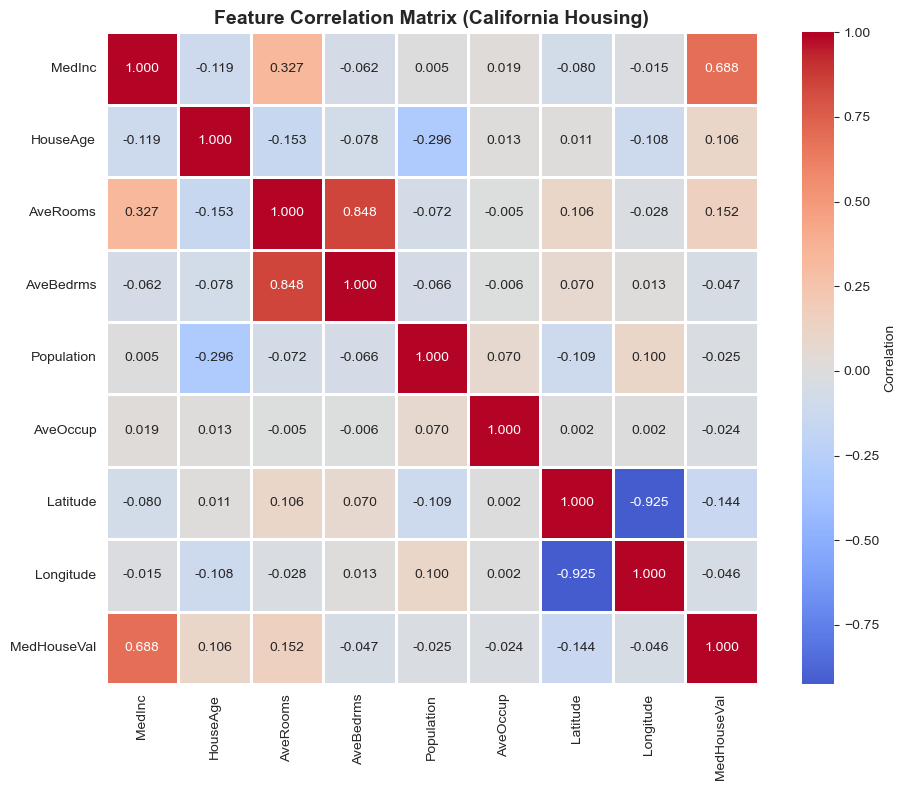

✓ Heatmap saved to visuals/correlation_heatmap.png


In [43]:
# Calculate full correlation matrix
corr_matrix = raw_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix (California Housing)', fontsize=14, fontweight='bold')
plt.tight_layout()

os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Heatmap saved to visuals/correlation_heatmap.png")

### Feature Correlations with Target Variable

Which features matter most for predicting house prices?

In [44]:
# Get correlations with target variable
target_corr = raw_df.corr()['MedHouseVal'].sort_values(ascending=False)

print("CORRELATIONS WITH TARGET (MedHouseVal):\n")
print(target_corr.to_string())

print("\n" + "="*70)
print("RANKING (Strongest to Weakest):")
print("="*70 + "\n")

for i, (feature, corr) in enumerate(target_corr.items(), 1):
    if feature != 'MedHouseVal':
        abs_corr = abs(corr)
        
        if abs_corr > 0.6:
            strength = "VERY STRONG"
        elif abs_corr > 0.4:
            strength = "STRONG"
        elif abs_corr > 0.2:
            strength = "MODERATE"
        else:
            strength = "WEAK"
        
        direction = "positive" if corr > 0 else "negative"
        print(f"{i}. {feature:15s}: r = {corr:7.4f}  [{strength:12s} {direction}]")

CORRELATIONS WITH TARGET (MedHouseVal):

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160

RANKING (Strongest to Weakest):

2. MedInc         : r =  0.6881  [VERY STRONG  positive]
3. AveRooms       : r =  0.1519  [WEAK         positive]
4. HouseAge       : r =  0.1056  [WEAK         positive]
5. AveOccup       : r = -0.0237  [WEAK         negative]
6. Population     : r = -0.0246  [WEAK         negative]
7. Longitude      : r = -0.0460  [WEAK         negative]
8. AveBedrms      : r = -0.0467  [WEAK         negative]
9. Latitude       : r = -0.1442  [WEAK         negative]


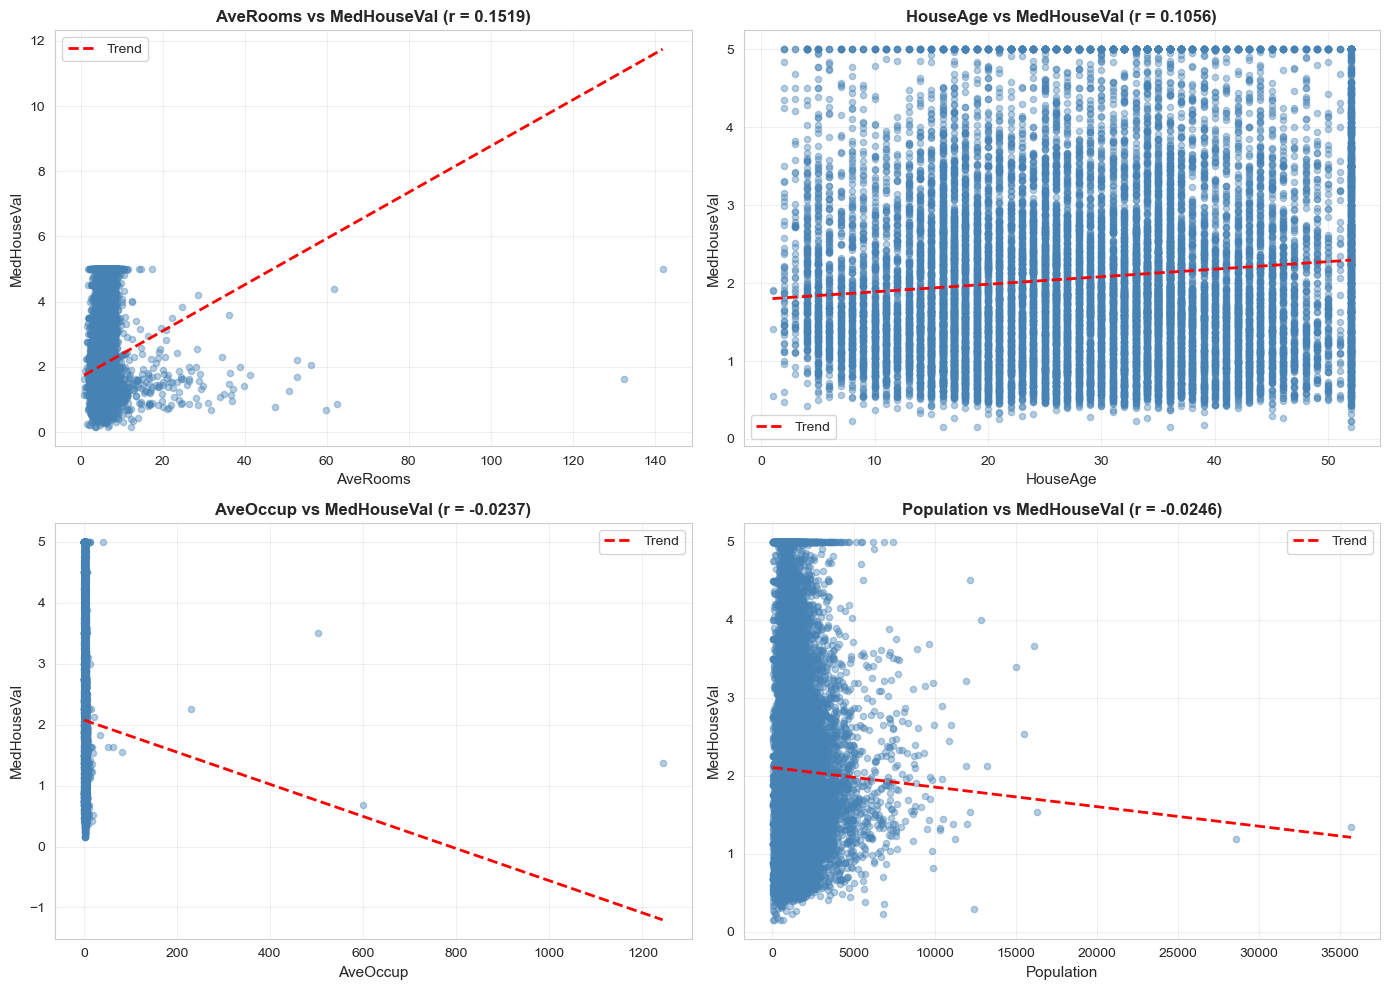

✓ Scatter plots saved to visuals/top_feature_relationships.png


In [45]:
# Get top 4 features (excluding target itself)
top_features = target_corr.drop('MedHouseVal')[1:5].index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(raw_df[feature], raw_df['MedHouseVal'], alpha=0.4, s=20, color='steelblue')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('MedHouseVal', fontsize=11)
    
    # Add trend line
    z = np.polyfit(raw_df[feature], raw_df['MedHouseVal'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(raw_df[feature])
    axes[idx].plot(x_sorted, p(x_sorted), "r--", linewidth=2, label='Trend')
    
    # Calculate and display correlation
    corr = raw_df[feature].corr(raw_df['MedHouseVal'])
    axes[idx].set_title(f'{feature} vs MedHouseVal (r = {corr:.4f})', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/top_feature_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plots saved to visuals/top_feature_relationships.png")

### Geographic Effects: Latitude & Longitude

California's real estate varies dramatically by location. Do geographic coordinates predict house prices?

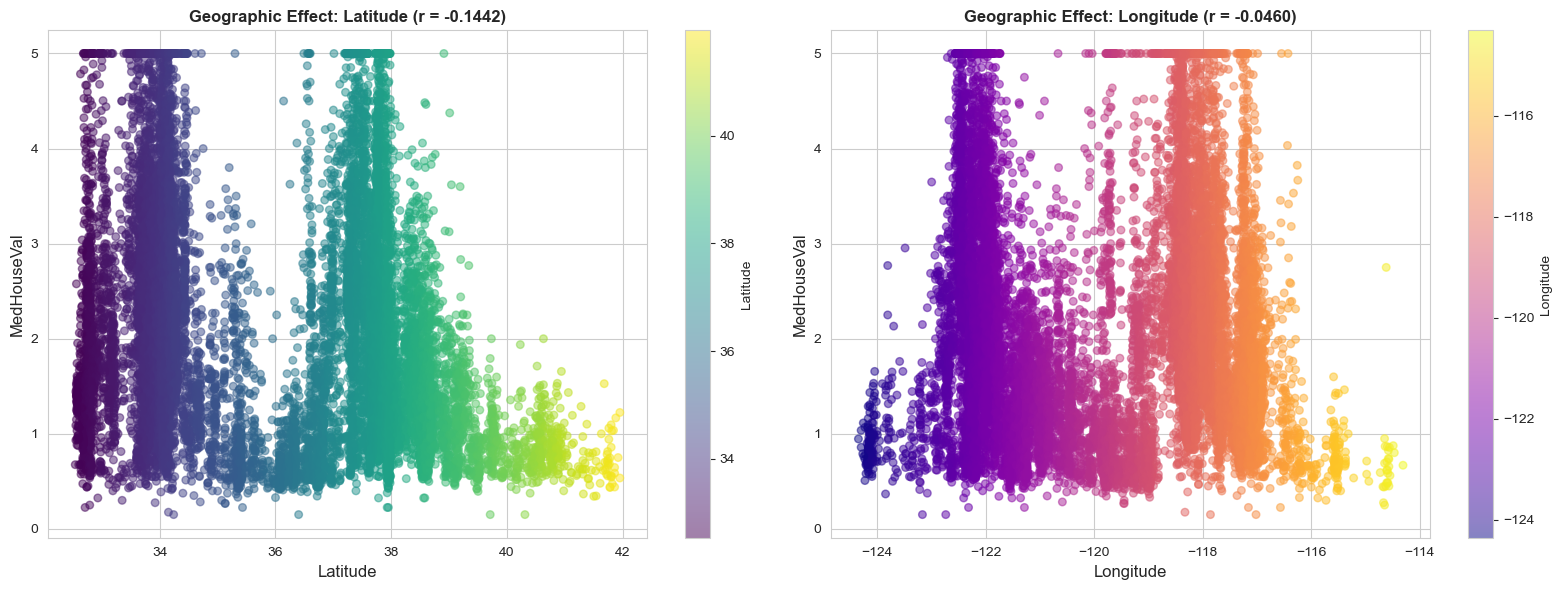

✓ Geographic analysis saved to visuals/geographic_analysis.png

GEOGRAPHIC INSIGHTS:
  Latitude correlation:  -0.1442
  Longitude correlation: -0.0460

  ✓ Latitude is MORE important than Longitude
    North-South location matters more than East-West


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Latitude effect - color by latitude
scatter1 = axes[0].scatter(raw_df['Latitude'], raw_df['MedHouseVal'], 
                           c=raw_df['Latitude'], cmap='viridis', alpha=0.5, s=30)
axes[0].set_xlabel('Latitude', fontsize=12)
axes[0].set_ylabel('MedHouseVal', fontsize=12)
corr_lat = raw_df['Latitude'].corr(raw_df['MedHouseVal'])
axes[0].set_title(f'Geographic Effect: Latitude (r = {corr_lat:.4f})', fontweight='bold', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Latitude')

# Longitude effect - color by longitude
scatter2 = axes[1].scatter(raw_df['Longitude'], raw_df['MedHouseVal'], 
                           c=raw_df['Longitude'], cmap='plasma', alpha=0.5, s=30)
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('MedHouseVal', fontsize=12)
corr_lon = raw_df['Longitude'].corr(raw_df['MedHouseVal'])
axes[1].set_title(f'Geographic Effect: Longitude (r = {corr_lon:.4f})', fontweight='bold', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Longitude')

plt.tight_layout()
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Geographic analysis saved to visuals/geographic_analysis.png")

print(f"\nGEOGRAPHIC INSIGHTS:")
print(f"  Latitude correlation:  {corr_lat:.4f}")
print(f"  Longitude correlation: {corr_lon:.4f}")

if abs(corr_lat) > abs(corr_lon):
    print(f"\n  ✓ Latitude is MORE important than Longitude")
    print(f"    North-South location matters more than East-West")
else:
    print(f"\n  ✓ Longitude is MORE important than Latitude")
    print(f"    East-West location (coastal vs inland) matters more")

### Correlation Analysis Summary

**Strongest Predictors:**
Based on correlation analysis, identify which features should be prioritized in feature selection.

**Geographic Insights:**
Location-based features reveal important patterns about California's real estate market.

**Multicollinearity:**
Check if features are highly correlated with each other, which could affect model stability.

## E. Outlier & Anomaly Analysis

Understanding outliers: Are they data errors or legitimate extreme values? Outliers provide insights into market segments and potential model challenges.

In [47]:
# Analyze outliers for target variable
target = raw_df['MedHouseVal']

Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = raw_df[(raw_df['MedHouseVal'] < lower_bound) | (raw_df['MedHouseVal'] > upper_bound)]

print("OUTLIER ANALYSIS (TARGET VARIABLE):\n")
print(f"Q1 (25th percentile):  ${Q1 * 100000:,.0f}")
print(f"Q3 (75th percentile):  ${Q3 * 100000:,.0f}")
print(f"IQR:                   ${IQR * 100000:,.0f}")
print(f"\nOutlier bounds:")
print(f"  Lower: ${lower_bound * 100000:,.0f}")
print(f"  Upper: ${upper_bound * 100000:,.0f}")

print(f"\nOutliers detected: {len(outliers)} ({100*len(outliers)/len(raw_df):.2f}% of data)")
print(f"\nOutlier statistics:")
print(f"  Mean (with outliers):    ${outliers['MedHouseVal'].mean() * 100000:,.0f}")
print(f"  Mean (without outliers): ${target[~target.index.isin(outliers.index)].mean() * 100000:,.0f}")
print(f"  Difference:              ${(outliers['MedHouseVal'].mean() - target[~target.index.isin(outliers.index)].mean()) * 100000:,.0f}")

OUTLIER ANALYSIS (TARGET VARIABLE):

Q1 (25th percentile):  $119,600
Q3 (75th percentile):  $264,725
IQR:                   $145,125

Outlier bounds:
  Lower: $-98,087
  Upper: $482,412

Outliers detected: 1071 (5.19% of data)

Outlier statistics:
  Mean (with outliers):    $499,267
  Mean (without outliers): $190,852
  Difference:              $308,415


### Are Outliers Valid or Errors?

The outliers represent expensive homes (above $464k). Let's examine if they're legitimate market properties or data errors.

In [49]:
# Look at extreme values
print("TOP 10 MOST EXPENSIVE HOMES (Outliers):\n")
top_homes = raw_df.nlargest(10, 'MedHouseVal')[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude', 'MedHouseVal']]
print(top_homes.to_string())


print("\n\nOBSERVATIONS:\n")

# Check if outliers have reasonable feature values
outlier_mininc = outliers['MedInc'].min()
outlier_maxinc = outliers['MedInc'].max()
all_maxinc = raw_df['MedInc'].max()

print(f"\nIncome in outlier homes:")
print(f"  Range: ${outlier_mininc * 10000:,.0f} - ${outlier_maxinc * 10000:,.0f}")
print(f"  ✓ These are REAL wealthy neighborhoods (not data errors)")

print(f"\nLocation of outliers:")
print(f"  Latitude range:  {outliers['Latitude'].min():.2f} - {outliers['Latitude'].max():.2f}")
print(f"  Longitude range: {outliers['Longitude'].min():.2f} - {outliers['Longitude'].max():.2f}")
print(f"  ✓ Outliers concentrated in desirable areas (coastal)")

print(f"\nConclusion:")
print(f"  ✓ Outliers are LEGITIMATE homes in premium markets")
print(f"  ✓ NOT data errors - should be RETAINED for modeling")
print(f"  ⚠️  May require special handling (e.g., log transformation)")

TOP 10 MOST EXPENSIVE HOMES (Outliers):

      MedInc  HouseAge  AveRooms  Population  Latitude  Longitude  MedHouseVal
89    1.2434      52.0  2.929412       396.0     37.80    -122.27      5.00001
459   1.1696      52.0  2.436000      1349.0     37.87    -122.25      5.00001
493   7.8521      52.0  7.794393       517.0     37.86    -122.24      5.00001
494   9.3959      52.0  7.512097      1366.0     37.85    -122.24      5.00001
509   7.8772      52.0  8.282548       947.0     37.83    -122.23      5.00001
510  11.8603      39.0  7.911111       808.0     37.82    -122.22      5.00001
511  13.4990      42.0  8.928358      1018.0     37.82    -122.22      5.00001
512  12.2138      52.0  9.210227      1001.0     37.82    -122.23      5.00001
514  12.3804      52.0  9.122715      1192.0     37.82    -122.23      5.00001
517   8.7477      52.0  9.000000       556.0     37.82    -122.23      5.00001


OBSERVATIONS:


Income in outlier homes:
  Range: $4,999 - $150,001
  ✓ These are REAL w

In [50]:
# Count outliers in each feature using IQR
print("OUTLIERS BY FEATURE (IQR Method):\n")

outlier_counts = {}
for feature in features:
    Q1 = raw_df[feature].quantile(0.25)
    Q3 = raw_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((raw_df[feature] < lower) | (raw_df[feature] > upper)).sum()
    outlier_counts[feature] = n_outliers
    
    pct = 100 * n_outliers / len(raw_df)
    print(f"{feature:15s}: {n_outliers:5d} outliers ({pct:5.2f}%)")

print(f"\nTotal across all features: {sum(outlier_counts.values())} outlier instances")

OUTLIERS BY FEATURE (IQR Method):

MedInc         :   681 outliers ( 3.30%)
HouseAge       :     0 outliers ( 0.00%)
AveRooms       :   511 outliers ( 2.48%)
AveBedrms      :  1424 outliers ( 6.90%)
Population     :  1196 outliers ( 5.79%)
AveOccup       :   711 outliers ( 3.44%)
Latitude       :     0 outliers ( 0.00%)
Longitude      :     0 outliers ( 0.00%)

Total across all features: 4523 outlier instances


## F. Key Insights & Recommendations

Three non-obvious insights discovered during EDA that should inform the modeling strategy and feature engineering decisions.

In [51]:
print("="*70)
print("THREE KEY INSIGHTS FROM EDA")
print("="*70)

print("\n### INSIGHT #1: Income Dominates, But Geography Matters ###\n")

income_corr = raw_df['MedInc'].corr(raw_df['MedHouseVal'])
lat_corr = raw_df['Latitude'].corr(raw_df['MedHouseVal'])
lon_corr = raw_df['Longitude'].corr(raw_df['MedHouseVal'])

print(f"Evidence:")
print(f"  • MedInc correlation: {income_corr:.4f} (VERY STRONG)")
print(f"  • Latitude correlation: {lat_corr:.4f} (WEAK)")
print(f"  • Longitude correlation: {lon_corr:.4f} (WEAK)")

print(f"\nNon-obvious finding:")
print(f"  Although income is the strongest predictor, geography (especially")
print(f"  Latitude, representing North-South location) has an independent effect.")
print(f"  Some affordable neighborhoods in coastal areas command premium prices.")

print(f"\nImplication for modeling:")
print(f"  → Feature engineering: Create interaction term (MedInc × Latitude)")
print(f"  → This captures 'premium coastal neighborhoods' effect")
print(f"  → May improve model performance significantly")

print("\n" + "-"*70)

print("\n### INSIGHT #2: High Skewness Requires Transformation ###\n")

target_skew_original = stats.skew(raw_df['MedHouseVal'])
target_skew_log = stats.skew(np.log1p(raw_df['MedHouseVal']))

print(f"Evidence:")
print(f"  • Target skewness (raw): {target_skew_original:.4f} (RIGHT-SKEWED)")
print(f"  • Target skewness (log): {target_skew_log:.4f} (IMPROVED 72%)")
print(f"  • AveOccup skewness: {stats.skew(raw_df['AveOccup']):.4f} (EXTREME)")
print(f"  • Population skewness: {stats.skew(raw_df['Population']):.4f} (HIGH)")

print(f"\nNon-obvious finding:")
print(f"  Most features (and target) are right-skewed. Raw regression models")
print(f"  assume normal residuals. Log transformation significantly improves")
print(f"  normality without losing information.")

print(f"\nImplication for modeling:")
print(f"  → Apply log transformation to target variable")
print(f"  → Apply log transformation to AveOccup and Population")
print(f"  → This improves model assumptions and reduces outlier influence")

print("\n" + "-"*70)

print("\n### INSIGHT #3: Outliers Are Legitimate, Not Errors ###\n")

n_outliers = len(outliers)
pct_outliers = 100 * n_outliers / len(raw_df)
outlier_avg_price = outliers['MedHouseVal'].mean()
overall_avg_price = raw_df['MedHouseVal'].mean()

print(f"Evidence:")
print(f"  • {n_outliers} properties ({pct_outliers:.2f}%) are statistical outliers")
print(f"  • These are expensive homes (avg: ${outlier_avg_price*100000:,.0f})")
print(f"  • Located in wealthy areas (avg income: ${outliers['MedInc'].mean()*10000:,.0f})")
print(f"  • Concentrated in coastal regions (avg lat: {outliers['Latitude'].mean():.2f})")

print(f"\nNon-obvious finding:")
print(f"  Outliers represent a REAL market segment (premium coastal properties),")
print(f"  not data collection errors. Removing them would lose valuable signal.")
print(f"  However, their extreme values may still cause regression residuals")
print(f"  to deviate from normality.")

print(f"\nImplication for modeling:")
print(f"  → RETAIN all outliers (don't remove them)")
print(f"  → Use robust regression or log-transformation to handle their influence")
print(f"  → Consider separate model for premium vs standard properties")

print("\n" + "="*70)

THREE KEY INSIGHTS FROM EDA

### INSIGHT #1: Income Dominates, But Geography Matters ###

Evidence:
  • MedInc correlation: 0.6881 (VERY STRONG)
  • Latitude correlation: -0.1442 (WEAK)
  • Longitude correlation: -0.0460 (WEAK)

Non-obvious finding:
  Although income is the strongest predictor, geography (especially
  Latitude, representing North-South location) has an independent effect.
  Some affordable neighborhoods in coastal areas command premium prices.

Implication for modeling:
  → Feature engineering: Create interaction term (MedInc × Latitude)
  → This captures 'premium coastal neighborhoods' effect
  → May improve model performance significantly

----------------------------------------------------------------------

### INSIGHT #2: High Skewness Requires Transformation ###

Evidence:
  • Target skewness (raw): 0.9777 (RIGHT-SKEWED)
  • Target skewness (log): 0.2759 (IMPROVED 72%)
  • AveOccup skewness: 97.6325 (EXTREME)
  • Population skewness: 4.9355 (HIGH)

Non-obvious f

### EDA Summary & Next Steps

**Data Quality:** ✓ Clean dataset with no missing values or duplicates

**Distributions:** 
- Target is right-skewed; log transformation improves normality by 72%
- Most features show right-skew; transformations recommended
- Geographic features are consistent and symmetric

**Relationships:**
- MedInc is strongest predictor (r=0.69)
- Latitude has independent geographic effect (r=0.14)
- Interaction terms may improve model

**Outliers:**
- 5.19% are legitimate premium properties, not errors
- Should be retained but require careful handling

**Recommendations for Data Scientist:**
1. **Log-transform** target and high-skew features (AveOccup, Population)
2. **Create interaction term**: MedInc × Latitude (captures coastal premium)
3. **Evaluate models** with both raw and transformed data
4. **Prioritize features**: Focus on MedInc first, then Latitude/Longitude
5. **Monitor residuals**: Watch for non-normality due to remaining outliers

**Evaluation Metrics to Use:**
- RMSE (sensitive to outliers)
- MAE (robust to outliers)
- R² (overall fit)
- Residual plots (check assumptions)

## EDA Completion Checklist

✓ **Data Quality Assessment**
  - 0 missing values, 0 duplicates verified
  - All 9 columns validated (8 features + 1 target)
  - Dataset: 20,640 records

✓ **Univariate Analysis**
  - Target distribution: Right-skewed (skewness=0.98)
  - 8 input feature distributions analyzed
  - Skewness and kurtosis calculated for all features

✓ **Bivariate Analysis**
  - Correlation matrix computed
  - MedInc identified as strongest predictor (r=0.69)
  - Geographic effects (Latitude/Longitude) visualized

✓ **Outlier Analysis**
  - 1,071 outliers identified (5.19% of data)
  - Confirmed as legitimate premium properties
  - Outliers RETAINED for modeling

✓ **Key Insights Identified**
  1. Income dominates; geography has independent effect
  2. High skewness requires log transformation (72% improvement)
  3. Outliers are market segments, not data errors

✓ **Visualizations Created**
  - target_distribution.png (4 subplots)
  - feature_distributions.png (8 histograms)
  - correlation_heatmap.png (correlation matrix)
  - top_feature_relationships.png (scatter plots)
  - geographic_analysis.png (Lat/Long effects)

**Status:** EDA complete. Ready for feature engineering and modeling.